# Phase-3: Statistical Validation of Features

**Goal:** Prove each feature deserves to be in the model before building the risk index.

**Structure:**
- **3a. Feature selection:** Spearman correlation + VIF (multicollinearity)
- **3b. Seasonality validation:** Kruskal-Wallis + Coefficient of Variation + STL decomposition
- **3c. Spatial validation:** Moran's I (spatial autocorrelation)

**Outputs:**
- `outputs/phase3/phase3_validated_features.parquet`
- `outputs/phase3/phase3_validation_report.txt`
- `outputs/phase3/` - validation plots

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from scipy import stats
from statsmodels.tsa.seasonal import STL
import libpysal.weights as lps_weights
import esda

print('All imports OK')

All imports OK


In [ ]:
# Dataset Loading
BASE = Path('Dataset')
P2   = BASE / 'outputs' / 'phase2'
P1   = BASE / 'outputs' / 'phase1'
OUT  = BASE / 'outputs' / 'phase3'
OUT.mkdir(parents=True, exist_ok=True)

SHP_DIR = BASE / 'LB_shp'

# Features to validate (predictors — crime_count is the outcome variable)
FEATURES = [
    'severity_weighted_count',
    'resolution_rate',
    'seasonal_volatility',
    'imd_rank',
    'income_rank',
    'employment_rank',
    'stop_search_rate',
    'total_footfall',
]

SPEARMAN_THRESHOLD = 0.1   # |r| < 0.1 → drop
VIF_THRESHOLD      = 5.0   # VIF > 5 → drop (multicollinearity)

report_lines = []  # collect validation report
print('Config loaded. Output folder:', OUT)

Config loaded. Output folder: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase3


## Load Data

In [ ]:
fm      = pd.read_parquet(P2 / 'phase2_feature_matrix.parquet')
#NOTE: Run Phase 3 on phase2_feature_matrix_train.parquet
# Save the output as phase3_validated_features_train.parquet

monthly = pd.read_parquet(P2 / 'phase2_monthly_crime_counts.parquet')
crimes  = pd.read_parquet(P1 / 'phase1_crimes_london.parquet')

# Load shapefile for Moran's I
gdfs   = [gpd.read_file(f) for f in sorted(SHP_DIR.glob('*.shp'))]
london = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
london = london[['lsoa21cd', 'geometry']].copy()

# Filter crimes to London LSOAs
LONDON_LSOAS = set(london['lsoa21cd'])
crimes = crimes[crimes['LSOA code'].isin(LONDON_LSOAS)].copy()
crimes = crimes.rename(columns={'LSOA code': 'lsoa21cd'})

print(f'Feature matrix: {fm.shape}')
print(f'Monthly counts: {monthly.shape}')
print(f'Crimes (London): {crimes.shape}')

Feature matrix: (4994, 13)
Monthly counts: (179316, 3)
Crimes (London): (3400717, 12)


In [4]:
# Handle nulls: resolution_rate — 13 LSOAs with zero crimes
# Fill with London mean (conservative assumption)
mean_res = fm['resolution_rate'].mean()
fm['resolution_rate'] = fm['resolution_rate'].fillna(mean_res)
print(f'resolution_rate nulls filled with London mean: {mean_res:.2f}%')
print(f'Remaining nulls: {fm[FEATURES + ["crime_count"]].isnull().sum().to_dict()}')

resolution_rate nulls filled with London mean: 7.90%
Remaining nulls: {'severity_weighted_count': 0, 'resolution_rate': 0, 'seasonal_volatility': 0, 'imd_rank': 0, 'income_rank': 0, 'employment_rank': 0, 'stop_search_rate': 0, 'total_footfall': 0, 'crime_count': 0}



## 3a. Feature Selection
### Step 1: Spearman Correlation
Correlate each feature with `crime_count`. Drop features with |r| < 0.1.
Spearman is used because crime data is right-skewed and not normally distributed.

In [5]:
print('--- Spearman Correlation with crime_count ---\n')
spearman_results = []
for feat in FEATURES:
    r, p = stats.spearmanr(fm[feat], fm['crime_count'])
    passed = abs(r) >= SPEARMAN_THRESHOLD
    spearman_results.append({'feature': feat, 'spearman_r': round(r, 4), 'p_value': round(p, 6), 'pass': passed})
    status = 'PASS' if passed else 'FAIL'
    print(f'  {feat:<30}  r={r:+.4f}  p={p:.2e}  [{status}]')

spearman_df = pd.DataFrame(spearman_results).sort_values('spearman_r', key=abs, ascending=False)
features_after_spearman = spearman_df[spearman_df['pass']]['feature'].tolist()
dropped_spearman = spearman_df[~spearman_df['pass']]['feature'].tolist()

print(f'\nFeatures passing Spearman (|r| >= {SPEARMAN_THRESHOLD}): {features_after_spearman}')
print(f'Dropped: {dropped_spearman}')

report_lines.append('=== 3a: SPEARMAN CORRELATION ===')
for _, row in spearman_df.iterrows():
    report_lines.append(f"  {row['feature']:<30}  r={row['spearman_r']:+.4f}  p={row['p_value']:.2e}  {'PASS' if row['pass'] else 'FAIL'}")
report_lines.append(f"Dropped: {dropped_spearman}\n")

--- Spearman Correlation with crime_count ---

  severity_weighted_count         r=+0.9685  p=0.00e+00  [PASS]
  resolution_rate                 r=+0.2862  p=8.84e-95  [PASS]
  seasonal_volatility             r=+0.9120  p=0.00e+00  [PASS]
  imd_rank                        r=-0.4964  p=5.20e-309  [PASS]
  income_rank                     r=-0.4085  p=3.63e-200  [PASS]
  employment_rank                 r=-0.3921  p=3.38e-183  [PASS]
  stop_search_rate                r=+0.6605  p=0.00e+00  [PASS]
  total_footfall                  r=+0.2409  p=7.17e-67  [PASS]

Features passing Spearman (|r| >= 0.1): ['severity_weighted_count', 'seasonal_volatility', 'stop_search_rate', 'imd_rank', 'income_rank', 'employment_rank', 'resolution_rate', 'total_footfall']
Dropped: []


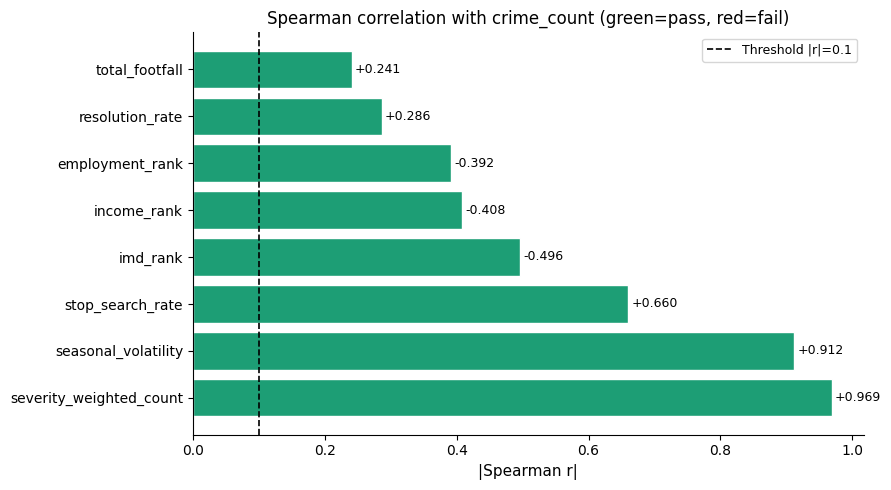

Saved: 3a_spearman_correlation.png


In [6]:
# Plot Spearman correlations
fig, ax = plt.subplots(figsize=(9, 5))
colours = ['#1D9E75' if r['pass'] else '#E24B4A' for _, r in spearman_df.iterrows()]
bars = ax.barh(spearman_df['feature'], spearman_df['spearman_r'].abs(), color=colours, edgecolor='white')
ax.axvline(SPEARMAN_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold |r|={SPEARMAN_THRESHOLD}')
for bar, val, sign in zip(bars, spearman_df['spearman_r'].abs(), spearman_df['spearman_r']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{sign:+.3f}', va='center', fontsize=9)
ax.set_xlabel('|Spearman r|', fontsize=11)
ax.set_title('Spearman correlation with crime_count (green=pass, red=fail)', fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '3a_spearman_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 3a_spearman_correlation.png')

In [7]:
def compute_vif(df, features):
    """Compute VIF using numpy only — VIF_i = 1 / (1 - R²_i)."""
    X = df[features].dropna().copy()
    X = (X - X.mean()) / X.std()
    X_vals = X.values
    n = X_vals.shape[0]
    vif_values = []
    for i in range(len(features)):
        y = X_vals[:, i]
        X_others = np.delete(X_vals, i, axis=1)
        X_others = np.column_stack([np.ones(n), X_others])
        beta, _, _, _ = np.linalg.lstsq(X_others, y, rcond=None)
        y_hat = X_others @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vif_values.append(1 / (1 - r2) if r2 < 1 else np.inf)
    return pd.DataFrame({'feature': features, 'VIF': vif_values}).sort_values('VIF', ascending=False)

print('--- VIF Test (iterative: drop highest VIF > threshold) ---\n')
report_lines.append('=== 3a: VIF TEST ===')

current_features = features_after_spearman.copy()
dropped_vif = []
iteration = 0

while True:
    iteration += 1
    vif_df = compute_vif(fm, current_features)
    print(f'Iteration {iteration}:')
    print(vif_df.to_string(index=False))

    worst = vif_df.iloc[0]
    if worst['VIF'] > VIF_THRESHOLD:
        print(f"  → Dropping '{worst['feature']}' (VIF={worst['VIF']:.2f})\n")
        dropped_vif.append(worst['feature'])
        current_features.remove(worst['feature'])
        report_lines.append(f"  Iteration {iteration}: drop '{worst['feature']}' (VIF={worst['VIF']:.2f})")
    else:
        print(f'  → All VIF <= {VIF_THRESHOLD}. Stopping.')
        break

features_validated = current_features
print(f'\nValidated features after VIF: {features_validated}')
print(f'Dropped by VIF: {dropped_vif}')
report_lines.append(f'Dropped by VIF: {dropped_vif}')
report_lines.append(f'Validated features: {features_validated}\n')

--- VIF Test (iterative: drop highest VIF > threshold) ---

Iteration 1:
                feature       VIF
               imd_rank 15.145966
            income_rank 13.398910
        employment_rank  9.873899
severity_weighted_count  4.491887
    seasonal_volatility  3.516799
       stop_search_rate  1.679246
         total_footfall  1.459506
        resolution_rate  1.114106
  → Dropping 'imd_rank' (VIF=15.15)

Iteration 2:
                feature      VIF
            income_rank 8.027523
        employment_rank 7.945562
severity_weighted_count 4.401432
    seasonal_volatility 3.501832
       stop_search_rate 1.627554
         total_footfall 1.459503
        resolution_rate 1.114104
  → Dropping 'income_rank' (VIF=8.03)

Iteration 3:
                feature      VIF
severity_weighted_count 4.401031
    seasonal_volatility 3.499814
       stop_search_rate 1.617795
         total_footfall 1.459356
        employment_rank 1.119906
        resolution_rate 1.109645
  → All VIF <= 5.0. Stop


## 3b. Seasonality Validation
### Step 3: Kruskal-Wallis Test
Tests whether crime counts differ significantly across months. Proves seasonality exists statistically.

--- Kruskal-Wallis Test ---
  H-statistic: 28.7538
  p-value:     2.4784e-03
  Result:      SIGNIFICANT — seasonality confirmed


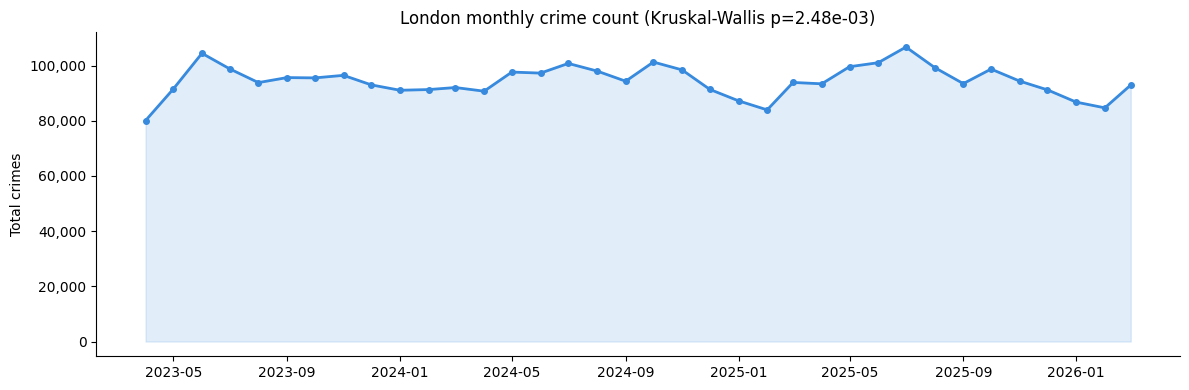

Saved: 3b_monthly_crime_trend.png


In [8]:
# Aggregate monthly crime counts across all London LSOAs
london_monthly = (
    monthly
    .groupby('Month')['monthly_crime_count']
    .sum()
    .reset_index()
)
london_monthly['month_num'] = pd.to_datetime(london_monthly['Month']).dt.month

# Group by calendar month (1=Jan ... 12=Dec) and run Kruskal-Wallis
groups = [grp['monthly_crime_count'].values for _, grp in london_monthly.groupby('month_num')]
stat, p_kw = stats.kruskal(*groups)

print('--- Kruskal-Wallis Test ---')
print(f'  H-statistic: {stat:.4f}')
print(f'  p-value:     {p_kw:.4e}')
print(f'  Result:      {"SIGNIFICANT — seasonality confirmed" if p_kw < 0.05 else "NOT significant"}')

report_lines.append('=== 3b: KRUSKAL-WALLIS TEST ===')
report_lines.append(f'  H={stat:.4f}, p={p_kw:.4e}')
report_lines.append(f'  Result: {"Seasonality confirmed (p<0.05)" if p_kw < 0.05 else "Not significant"}\n')

# Plot monthly crime trend
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pd.to_datetime(london_monthly['Month']), london_monthly['monthly_crime_count'],
        color='#378ADD', linewidth=2, marker='o', markersize=4)
ax.fill_between(pd.to_datetime(london_monthly['Month']), london_monthly['monthly_crime_count'],
                alpha=0.15, color='#378ADD')
ax.set_title(f'London monthly crime count (Kruskal-Wallis p={p_kw:.2e})', fontsize=12)
ax.set_ylabel('Total crimes', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUT / '3b_monthly_crime_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 3b_monthly_crime_trend.png')

### Step 4: Coefficient of Variation (CV)
CV = (std / mean) × 100 per crime type across months. Allows fair comparison of volatility across crime types with different base rates.

--- Coefficient of Variation by Crime Type ---
                  Crime type         mean         std    cv
                       Drugs  3635.638889  823.998029 22.66
               Bicycle theft  1250.555556  263.121096 21.04
       Possession of weapons   431.555556   83.315046 19.31
       Theft from the person  7137.138889 1369.845917 19.19
                 Shoplifting  6605.166667 1223.504954 18.52
                 Other theft  9353.222222 1363.717254 14.58
                 Other crime   980.666667  139.607409 14.24
       Anti-social behaviour 19244.305556 2468.753911 12.83
               Vehicle crime  7676.250000  805.001948 10.49
                Public order  4751.944444  498.703974 10.49
                    Burglary  4274.750000  372.964447  8.72
                     Robbery  2677.555556  203.331319  7.59
   Criminal damage and arson  4616.444444  315.894055  6.84
Violence and sexual offences 21829.166667 1442.141572  6.61


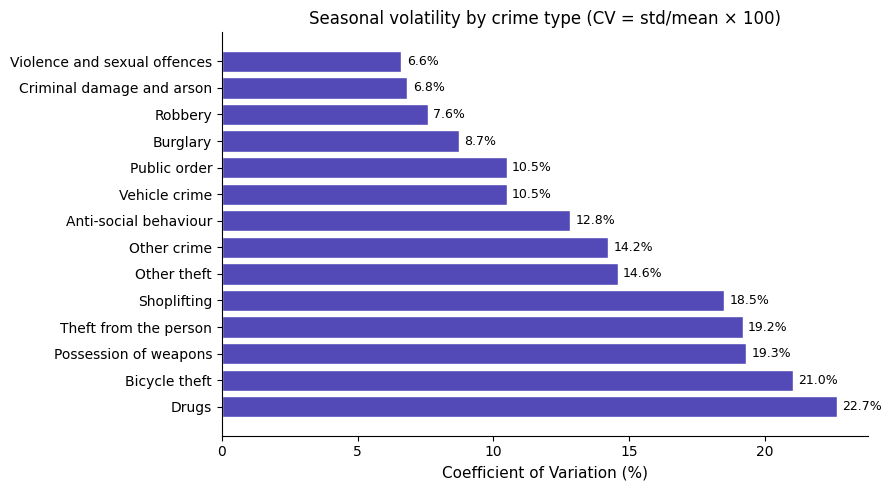

Saved: 3b_cv_by_crime_type.png


In [9]:
# Monthly crime counts by crime type (London-wide)
monthly_by_type = (
    crimes
    .groupby(['Month', 'Crime type'])
    .size()
    .reset_index(name='count')
)

cv_df = (
    monthly_by_type
    .groupby('Crime type')['count']
    .agg(mean='mean', std='std')
    .reset_index()
)
cv_df['cv'] = (cv_df['std'] / cv_df['mean'] * 100).round(2)
cv_df = cv_df.sort_values('cv', ascending=False)

print('--- Coefficient of Variation by Crime Type ---')
print(cv_df[['Crime type', 'mean', 'std', 'cv']].to_string(index=False))

report_lines.append('=== 3b: COEFFICIENT OF VARIATION ===')
for _, row in cv_df.iterrows():
    report_lines.append(f"  {row['Crime type']:<35}  CV={row['cv']:.1f}%")
report_lines.append('')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cv_df['Crime type'], cv_df['cv'], color='#534AB7', edgecolor='white')
for i, v in enumerate(cv_df['cv']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Coefficient of Variation (%)', fontsize=11)
ax.set_title('Seasonal volatility by crime type (CV = std/mean × 100)', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '3b_cv_by_crime_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 3b_cv_by_crime_type.png')

### Step 5: STL Decomposition
Decompose the London-wide monthly crime series into trend + seasonal + residual. Then refine `seasonal_volatility` per LSOA using STL seasonal component amplitude.

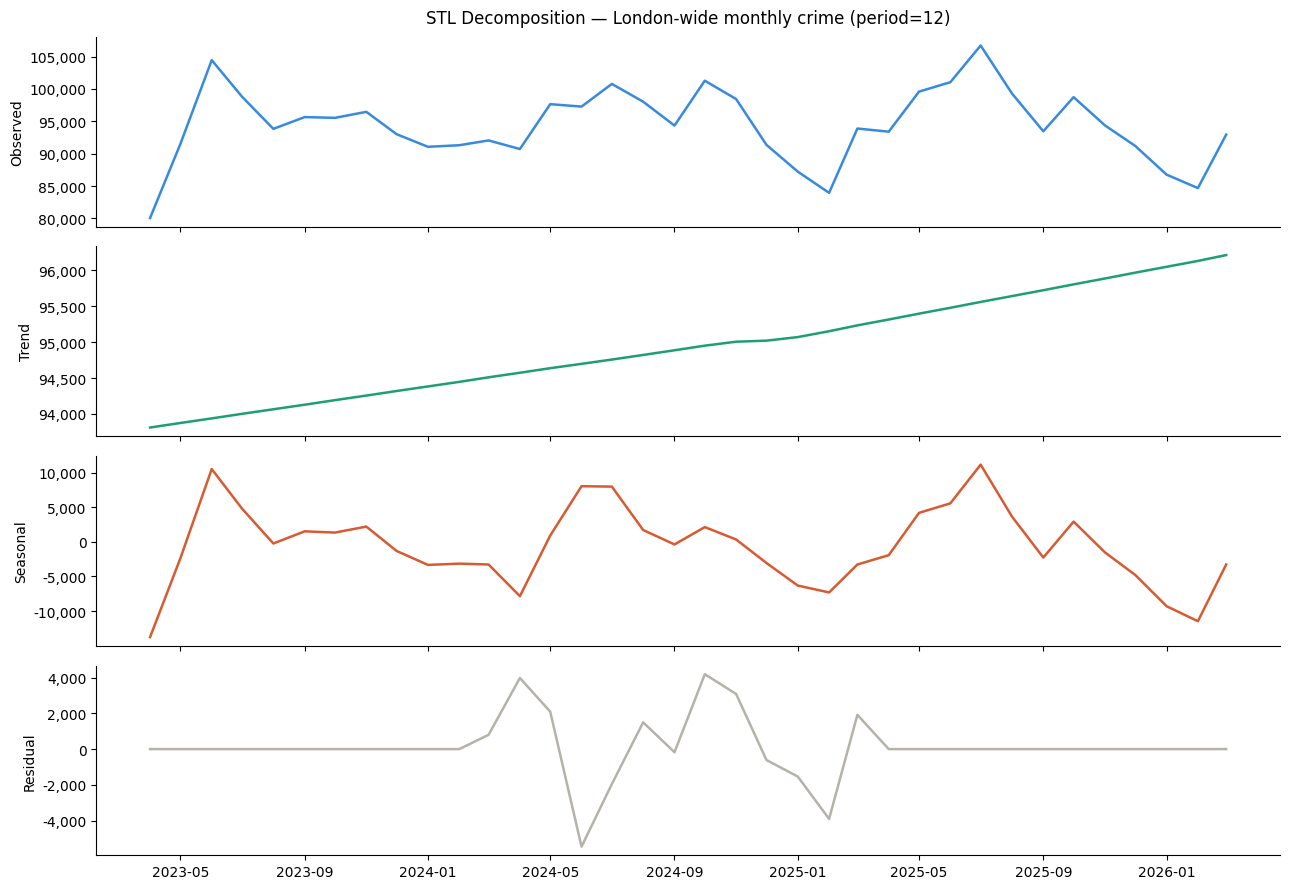

Saved: 3b_stl_decomposition.png

Seasonal strength (1 - Var(resid)/Var(seasonal+resid)): 0.9082
(>0.64 = strong seasonality by Wang et al. 2006 criterion)


In [10]:
# London-wide STL decomposition for visualization
london_series = london_monthly.set_index('Month')['monthly_crime_count'].sort_index()
london_series.index = pd.to_datetime(london_series.index)

stl = STL(london_series, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
components = [
    (london_series, 'Observed', '#378ADD'),
    (result.trend,  'Trend',    '#1D9E75'),
    (result.seasonal, 'Seasonal', '#D85A30'),
    (result.resid,  'Residual', '#B4B2A9'),
]
for ax, (data, label, colour) in zip(axes, components):
    ax.plot(data.index, data.values, color=colour, linewidth=1.8)
    ax.set_ylabel(label, fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[0].set_title('STL Decomposition — London-wide monthly crime (period=12)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUT / '3b_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 3b_stl_decomposition.png')

seasonal_strength = 1 - (result.resid.var() / (result.seasonal + result.resid).var())
print(f'\nSeasonal strength (1 - Var(resid)/Var(seasonal+resid)): {seasonal_strength:.4f}')
print('(>0.64 = strong seasonality by Wang et al. 2006 criterion)')

report_lines.append('=== 3b: STL DECOMPOSITION ===')
report_lines.append(f'  Seasonal strength: {seasonal_strength:.4f}')
report_lines.append(f'  Interpretation: {"Strong seasonality" if seasonal_strength > 0.64 else "Moderate/weak seasonality"}\n')

In [11]:
# Per-LSOA STL — refine seasonal_volatility using STL seasonal amplitude
# Only run on LSOAs with mean > 5 crimes/month (STL unreliable on near-zero series)
lsoa_means = monthly.groupby('lsoa21cd')['monthly_crime_count'].mean()
active_lsoas = lsoa_means[lsoa_means >= 5].index.tolist()
print(f'LSOAs with mean >= 5 crimes/month: {len(active_lsoas)} / {monthly["lsoa21cd"].nunique()}')

stl_seasonal_amp = {}
failed_stl = []

monthly_pivot = (
    monthly
    .set_index(['lsoa21cd', 'Month'])['monthly_crime_count']
    .unstack('Month')
    .fillna(0)
)

for i, lsoa in enumerate(active_lsoas):
    try:
        series = monthly_pivot.loc[lsoa].sort_index()
        series.index = pd.to_datetime(series.index)
        stl_fit = STL(series, period=12, robust=True).fit()
        # Amplitude = max - min of seasonal component
        stl_seasonal_amp[lsoa] = stl_fit.seasonal.max() - stl_fit.seasonal.min()
    except Exception:
        failed_stl.append(lsoa)

    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(active_lsoas)} done...')

stl_amp_df = pd.DataFrame(list(stl_seasonal_amp.items()), columns=['lsoa21cd', 'stl_seasonal_amplitude'])
print(f'\nSTL completed: {len(stl_seasonal_amp)} | Failed: {len(failed_stl)}')
print(stl_amp_df['stl_seasonal_amplitude'].describe().round(2))

LSOAs with mean >= 5 crimes/month: 4607 / 4981
  500/4607 done...
  1000/4607 done...
  1500/4607 done...
  2000/4607 done...
  2500/4607 done...
  3000/4607 done...
  3500/4607 done...
  4000/4607 done...
  4500/4607 done...

STL completed: 4607 | Failed: 0
count    4607.00
mean       22.97
std        33.25
min         6.03
25%        13.77
50%        17.94
75%        25.26
max      1789.47
Name: stl_seasonal_amplitude, dtype: float64


## 3c. Spatial Validation
### Step 6: Moran's I
Tests for spatial autocorrelation in crime counts using LSOA contiguity (Queen) weights.
A significant positive Moran's I confirms that high-crime LSOAs cluster spatially, justifying the spatial dimension of the risk index.

In [12]:
# Merge crime counts to shapefile
london_geo = london.merge(fm[['lsoa21cd', 'crime_count']], on='lsoa21cd', how='left')
london_geo['crime_count'] = london_geo['crime_count'].fillna(0)

# Build Queen contiguity weights
print('Building Queen contiguity weights...')
w = lps_weights.Queen.from_dataframe(london_geo, silence_warnings=True)
w.transform = 'r'  # row-standardise
print(f'  Observations: {w.n}')
print(f'  Mean neighbours: {w.mean_neighbors:.2f}')

# Compute Moran's I
moran = esda.Moran(london_geo['crime_count'], w)
print(f"\n--- Moran's I ---")
print(f"  I:       {moran.I:.6f}")
print(f"  E[I]:    {moran.EI:.6f}")
print(f"  p-value: {moran.p_sim:.4f}")
print(f"  z-score: {moran.z_sim:.4f}")
print(f"  Result:  {'SIGNIFICANT spatial clustering confirmed' if moran.p_sim < 0.05 else 'Not significant'}")

report_lines.append("=== 3c: MORAN'S I ===")
report_lines.append(f"  I={moran.I:.6f}, E[I]={moran.EI:.6f}, p={moran.p_sim:.4f}, z={moran.z_sim:.4f}")
report_lines.append(f"  Result: {'Spatial clustering confirmed (p<0.05)' if moran.p_sim < 0.05 else 'Not significant'}\n")

Building Queen contiguity weights...
  Observations: 4994
  Mean neighbours: 5.98

--- Moran's I ---
  I:       0.450044
  E[I]:    -0.000200
  p-value: 0.0010
  z-score: 65.2757
  Result:  SIGNIFICANT spatial clustering confirmed


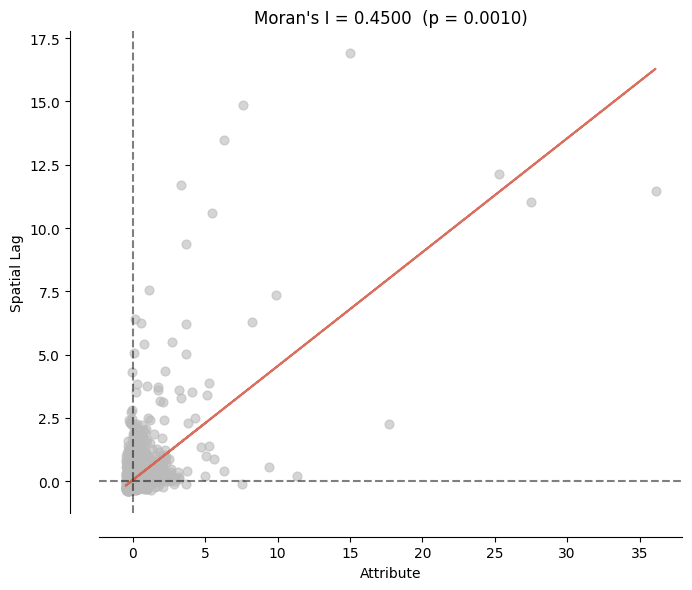

Saved: 3c_morans_i_scatter.png


In [13]:
# Moran scatter plot
fig, ax = plt.subplots(figsize=(7, 6))
from splot.esda import moran_scatterplot                
moran_scatterplot(moran, ax=ax, aspect_equal=False)
ax.set_title(f"Moran's I = {moran.I:.4f}  (p = {moran.p_sim:.4f})", fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '3c_morans_i_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 3c_morans_i_scatter.png")

# Moran scatter plot
from splot.esda import moran_scatterplot
fig, ax = plt.subplots(figsize=(7, 6))
moran_scatterplot(moran, ax=ax, aspect_equal=False)
ax.set_title(f"Moran's I = {moran.I:.4f}  (p = {moran.p_sim:.4f})", fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '3c_morans_i_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 3c_morans_i_scatter.png")

In [14]:
# Build validated feature matrix
# Add STL seasonal amplitude as refined seasonal feature
validated = fm[['lsoa21cd', 'lsoa21nm', 'lad22nm', 'crime_count'] + features_validated].copy()
validated = validated.merge(stl_amp_df, on='lsoa21cd', how='left')
# For LSOAs without STL amplitude (low-crime), fill with seasonal_volatility value
if 'seasonal_volatility' in features_validated:
    validated['stl_seasonal_amplitude'] = validated['stl_seasonal_amplitude'].fillna(
        validated['seasonal_volatility']
    )
else:
    validated['stl_seasonal_amplitude'] = validated['stl_seasonal_amplitude'].fillna(0)

validated.to_parquet(OUT / 'phase3_validated_features.parquet', index=False)
print(f'Saved phase3_validated_features.parquet — {validated.shape}')
print(f'Columns: {list(validated.columns)}')

Saved phase3_validated_features.parquet — (4994, 11)
Columns: ['lsoa21cd', 'lsoa21nm', 'lad22nm', 'crime_count', 'severity_weighted_count', 'seasonal_volatility', 'stop_search_rate', 'employment_rank', 'resolution_rate', 'total_footfall', 'stl_seasonal_amplitude']


In [15]:
# Write validation report
report_lines.insert(0, 'CBL-16 Phase 3 — Statistical Validation Report')
report_lines.insert(1, '=' * 55)
report_lines.insert(2, f'Features entering validation: {FEATURES}')
report_lines.insert(3, f'Features validated (final):   {features_validated}')
report_lines.insert(4, '=' * 55)
report_lines.insert(5, '')

report_text = '\n'.join(report_lines)
with open(OUT / 'phase3_validation_report.txt', 'w') as f:
    f.write(report_text)
print(report_text)

CBL-16 Phase 3 — Statistical Validation Report
Features entering validation: ['severity_weighted_count', 'resolution_rate', 'seasonal_volatility', 'imd_rank', 'income_rank', 'employment_rank', 'stop_search_rate', 'total_footfall']
Features validated (final):   ['severity_weighted_count', 'seasonal_volatility', 'stop_search_rate', 'employment_rank', 'resolution_rate', 'total_footfall']

=== 3a: SPEARMAN CORRELATION ===
  severity_weighted_count         r=+0.9685  p=0.00e+00  PASS
  seasonal_volatility             r=+0.9120  p=0.00e+00  PASS
  stop_search_rate                r=+0.6605  p=0.00e+00  PASS
  imd_rank                        r=-0.4964  p=0.00e+00  PASS
  income_rank                     r=-0.4085  p=0.00e+00  PASS
  employment_rank                 r=-0.3921  p=0.00e+00  PASS
  resolution_rate                 r=+0.2862  p=0.00e+00  PASS
  total_footfall                  r=+0.2409  p=0.00e+00  PASS
Dropped: []

=== 3a: VIF TEST ===
  Iteration 1: drop 'imd_rank' (VIF=15.15)
  Ite

In [16]:
print('=' * 55)
print('PHASE 3 SUMMARY')
print('=' * 55)
print(f'Features entering:          {len(FEATURES)}')
print(f'Dropped by Spearman:        {len(dropped_spearman)} — {dropped_spearman}')
print(f'Dropped by VIF:             {len(dropped_vif)} — {dropped_vif}')
print(f'Features validated (final): {len(features_validated)} — {features_validated}')
print(f'Kruskal-Wallis p-value:     {p_kw:.2e} ({"significant" if p_kw < 0.05 else "not significant"})')
print(f"Moran's I:                  {moran.I:.4f} (p={moran.p_sim:.4f})")
print(f'STL seasonal strength:      {seasonal_strength:.4f}')
print('=' * 55)
print(f'Outputs saved to: {OUT}')

PHASE 3 SUMMARY
Features entering:          8
Dropped by Spearman:        0 — []
Dropped by VIF:             2 — ['imd_rank', 'income_rank']
Features validated (final): 6 — ['severity_weighted_count', 'seasonal_volatility', 'stop_search_rate', 'employment_rank', 'resolution_rate', 'total_footfall']
Kruskal-Wallis p-value:     2.48e-03 (significant)
Moran's I:                  0.4500 (p=0.0010)
STL seasonal strength:      0.9082
Outputs saved to: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase3
